# Convolutional Neural Networks (CNN)

## Overview

In the previous notebooks, we classified MNIST digits with **fully connected** networks: every pixel connects to every neuron. That works, but it ignores the fact that images have **spatial structure** — nearby pixels form edges, loops and strokes.

A **Convolutional Neural Network (CNN)** exploits that structure with shared filters that scan the image. We keep the same problem, the same data split and the same PyTorch training loop as [deep-neural_network_pytorch](deep-neural_network_pytorch.ipynb), then swap the architecture to measure what convolution really brings.

### Our Journey So Far

| File | Topic | Key Concept |
|------|-------|-------------|
| [first_neural_network](first_neural_network.ipynb) | Neural Networks | Backpropagation, chain rule |
| [deep-neural_network_numpy](deep-neural_network_numpy.ipynb) | Deep Networks (NumPy) | ReLU, softmax, MNIST from scratch |
| [deep-neural_network_pytorch](deep-neural_network_pytorch.ipynb) | Fully connected (PyTorch) | Autograd, nn.Module, DataLoader |
| **deep-neural_network_cnn** | **CNN (PyTorch)** | **Convolution, pooling, spatial features** |

### What You'll Learn

- Why images need more than flattened vectors
- How `Conv2d` and `MaxPool2d` extract local patterns
- How a CNN compares to the fully connected PyTorch MLP on the same MNIST subset
- Where CNNs shine on this task, and where their limits still show

### Same Problem, Better Inductive Bias

We rebuild the MNIST classifier with a CNN, then compare it head-to-head with the fully connected PyTorch model (784 → 128 → 64 → 10).


## 1. Setup and Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12


PyTorch version: 2.8.0+cpu
Using device: cpu


## 2. Loading the MNIST Dataset

We use the **exact same dataset and preprocessing** as [deep-neural_network_pytorch](deep-neural_network_pytorch.ipynb) for a fair comparison.

- 70,000 grayscale images of handwritten digits (0-9)
- Each image is 28×28 = 784 pixels
- Subset of 10,000 samples with an 80/20 train/test split


In [2]:
print("Loading MNIST dataset (this may take a moment)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_full = mnist.data / 255.0
y_full = mnist.target.astype(int)

print("\nDataset loaded!")
print(f"X shape: {X_full.shape}  (samples, pixels)")
print(f"y shape: {y_full.shape}  (samples,)")
print(f"Classes: {np.unique(y_full)}")


Loading MNIST dataset (this may take a moment)...



Dataset loaded!
X shape: (70000, 784)  (samples, pixels)
y shape: (70000,)  (samples,)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [3]:
n_samples = 10000
X_subset = X_full[:n_samples]
y_subset = y_full[:n_samples]

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 8000 samples
Test set: 2000 samples


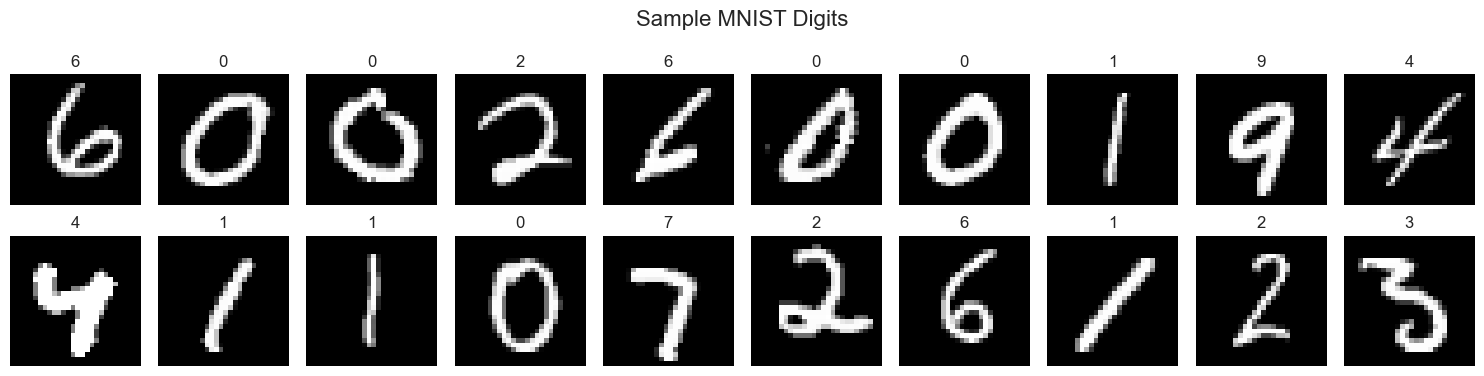

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"{y_train[idx]}", fontsize=12)
    ax.axis('off')

plt.suptitle('Sample MNIST Digits', fontsize=16)
plt.tight_layout()
plt.show()


## 3. Why CNNs for Images?

A fully connected network flattens the image into a vector of 784 values. Two problems follow:

1. **Spatial information is lost**, pixels that were neighbors become unrelated features.
2. **Parameter explosion**, every pixel connects to every neuron, so capacity grows fast and generalization suffers on limited data.

A CNN keeps the image as a 2D grid and applies **shared filters**. The same edge detector is reused across the whole image, which:

- reduces the number of parameters
- encodes translation-friendly local patterns (strokes, loops, corners)
- builds a hierarchy: edges → parts of digits → digit identity


In [5]:
# Same image, two representations
sample = X_train[0]

print("Fully connected view:")
print(f"  Shape: {sample.shape}  → flat vector of {sample.size} pixels")
print("  Spatial neighborhood between pixels is discarded")

print("\nCNN view:")
print(f"  Shape: {sample.reshape(1, 28, 28).shape}  → (channels, height, width)")
print("  Local structure is preserved for convolution")


Fully connected view:
  Shape: (784,)  → flat vector of 784 pixels
  Spatial neighborhood between pixels is discarded

CNN view:
  Shape: (1, 28, 28)  → (channels, height, width)
  Local structure is preserved for convolution


## 4. CNN Building Blocks

### Convolution (`nn.Conv2d`)

A small filter (for example 3×3) slides over the image and computes a weighted local sum at each position. Each filter learns one pattern: a vertical stroke, a curve, a corner, etc.

### ReLU

Same role as before: introduce non-linearity after each convolution.

### Max Pooling (`nn.MaxPool2d`)

Downsamples feature maps by keeping the strongest local response. This reduces spatial size, adds a bit of robustness to small shifts, and lowers computation.

### Flatten + Dense head

After the convolutional stack, feature maps are flattened and passed to a small fully connected classifier.


Input image:     (1, 1, 28, 28)
After Conv+ReLU: (1, 4, 28, 28)   → 4 feature maps, same spatial size (padding=1)
After MaxPool:   (1, 4, 14, 14)   → spatial size halved


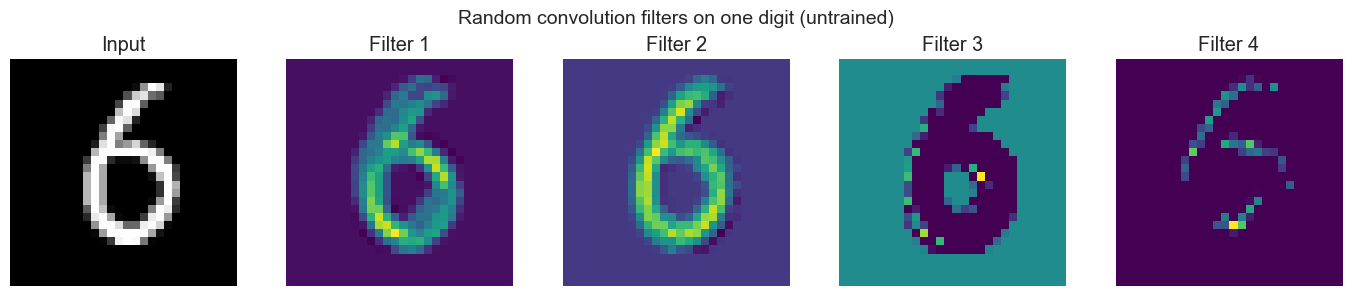

In [6]:
# Tiny demo: one convolution + one pooling on a single digit
demo_img = torch.FloatTensor(X_train[0].reshape(1, 1, 28, 28))  # (batch, channel, H, W)

conv = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
pool = nn.MaxPool2d(kernel_size=2, stride=2)

with torch.no_grad():
    feat = torch.relu(conv(demo_img))
    pooled = pool(feat)

print(f"Input image:     {tuple(demo_img.shape)}")
print(f"After Conv+ReLU: {tuple(feat.shape)}   → 4 feature maps, same spatial size (padding=1)")
print(f"After MaxPool:   {tuple(pooled.shape)}   → spatial size halved")

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(demo_img[0, 0].numpy(), cmap='gray')
axes[0].set_title('Input')
axes[0].axis('off')

for i in range(4):
    axes[i + 1].imshow(feat[0, i].numpy(), cmap='viridis')
    axes[i + 1].set_title(f'Filter {i + 1}')
    axes[i + 1].axis('off')

plt.suptitle('Random convolution filters on one digit (untrained)', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Architecture Comparison: MLP vs CNN

We keep the PyTorch MLP from the previous notebook and introduce a compact CNN.

| Component | MLP (previous) | CNN (this notebook) |
|-----------|----------------|---------------------|
| Input | Flattened 784 | Image (1, 28, 28) |
| Feature extraction | Dense layers only | Conv → ReLU → Pool (×2) |
| Classifier head | 128 → 64 → 10 | Flatten → 128 → 10 |
| Spatial inductive bias | None | Strong (local filters) |


In [7]:
class MLPClassifier(nn.Module):
    """Fully connected baseline: 784 → 128 → 64 → 10"""

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        # Accept either flat vectors or image tensors
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


class CNNClassifier(nn.Module):
    """
    Compact CNN for MNIST:
    (1, 28, 28)
      → Conv(16) + ReLU + MaxPool
      → Conv(32) + ReLU + MaxPool
      → Flatten (32 * 7 * 7)
      → Linear(128) + ReLU
      → Linear(10)
    """

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 → 14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 → 7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        # Accept flat vectors by reshaping to images
        if x.ndim == 2:
            x = x.view(-1, 1, 28, 28)
        x = self.features(x)
        return self.classifier(x)


mlp = MLPClassifier().to(device)
cnn = CNNClassifier().to(device)

print("MLP:")
print(mlp)
print("\nCNN:")
print(cnn)


MLP:
MLPClassifier(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

CNN:
CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [8]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp_params = count_params(mlp)
cnn_params = count_params(cnn)

print("=" * 60)
print("PARAMETER COUNT")
print("=" * 60)
print(f"MLP parameters: {mlp_params:,}")
print(f"CNN parameters: {cnn_params:,}")
if cnn_params < mlp_params:
    print(f"Difference:     {mlp_params - cnn_params:,} fewer params for the CNN")
else:
    print(f"Difference:     {cnn_params - mlp_params:,} more params for the CNN")
print("=" * 60)

print("\nCNN parameter breakdown:")
for name, param in cnn.named_parameters():
    print(f"  {name:<25} {str(tuple(param.shape)):<20} {param.numel():>7,} params")


PARAMETER COUNT
MLP parameters: 109,386
CNN parameters: 206,922
Difference:     97,536 more params for the CNN

CNN parameter breakdown:
  features.0.weight         (16, 1, 3, 3)            144 params
  features.0.bias           (16,)                     16 params
  features.3.weight         (32, 16, 3, 3)         4,608 params
  features.3.bias           (32,)                     32 params
  classifier.1.weight       (128, 1568)          200,704 params
  classifier.1.bias         (128,)                   128 params
  classifier.3.weight       (10, 128)              1,280 params
  classifier.3.bias         (10,)                     10 params


## 6. Data Preparation

The MLP consumes flat vectors `(batch, 784)`. The CNN needs image tensors `(batch, 1, 28, 28)`. We prepare both views from the same split, with the same batch size as the previous notebook.


In [9]:
BATCH_SIZE = 64

# Flat tensors for the MLP
X_train_flat = torch.FloatTensor(X_train)
X_test_flat = torch.FloatTensor(X_test)

# Image tensors for the CNN
X_train_img = torch.FloatTensor(X_train.reshape(-1, 1, 28, 28))
X_test_img = torch.FloatTensor(X_test.reshape(-1, 1, 28, 28))

y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

train_loader_mlp = DataLoader(TensorDataset(X_train_flat, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader_mlp = DataLoader(TensorDataset(X_test_flat, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

train_loader_cnn = DataLoader(TensorDataset(X_train_img, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader_cnn = DataLoader(TensorDataset(X_test_img, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print(f"MLP batch X shape: {next(iter(train_loader_mlp))[0].shape}")
print(f"CNN batch X shape: {next(iter(train_loader_cnn))[0].shape}")
print(f"Training batches: {len(train_loader_mlp)}")


MLP batch X shape: torch.Size([64, 784])
CNN batch X shape: torch.Size([64, 1, 28, 28])
Training batches: 125


## 7. Training Loop

Same training recipe for both models: `CrossEntropyLoss`, SGD with learning rate 0.1, 50 epochs, mini-batches of 64. The only intentional difference is the architecture.


In [10]:
def evaluate(model, data_loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss_sum += criterion(logits, y_batch).item() * y_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return loss_sum / total, correct / total


def train_model(model, train_loader, test_loader, lr=0.1, epochs=50, print_every=5, name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    print(f"Training {name}...")
    print(f"Learning rate: {lr}, Epochs: {epochs}, Batch size: {BATCH_SIZE}")
    print("=" * 70)

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader)
        test_loss, test_acc = evaluate(model, test_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        if epoch % print_every == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch + 1:3d}/{epochs}: "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2%} | "
                f"Test Acc: {test_acc:.2%}"
            )

    print("=" * 70)
    print(f"Final Test Accuracy ({name}): {history['test_acc'][-1]:.2%}")
    return history


## 8. Train the Fully Connected Baseline (MLP)


In [11]:
torch.manual_seed(42)
mlp = MLPClassifier().to(device)
history_mlp = train_model(
    mlp, train_loader_mlp, test_loader_mlp,
    lr=0.1, epochs=50, print_every=5, name="MLP (fully connected)"
)


Training MLP (fully connected)...
Learning rate: 0.1, Epochs: 50, Batch size: 64


Epoch   1/50: Train Loss: 0.6234, Train Acc: 82.21% | Test Acc: 83.80%


Epoch   6/50: Train Loss: 0.2038, Train Acc: 94.29% | Test Acc: 93.50%


Epoch  11/50: Train Loss: 0.1129, Train Acc: 96.95% | Test Acc: 94.95%


Epoch  16/50: Train Loss: 0.0667, Train Acc: 98.39% | Test Acc: 95.45%


...

Epoch  31/50: Train Loss: 0.0108, Train Acc: 99.94% | Test Acc: 96.05%


Epoch  36/50: Train Loss: 0.0070, Train Acc: 99.99% | Test Acc: 96.05%


Epoch  41/50: Train Loss: 0.0047, Train Acc: 100.00% | Test Acc: 96.05%


Epoch  46/50: Train Loss: 0.0035, Train Acc: 100.00% | Test Acc: 96.10%


Epoch  50/50: Train Loss: 0.0030, Train Acc: 100.00% | Test Acc: 95.85%
Final Test Accuracy (MLP (fully connected)): 95.85%


## 9. Train the CNN


In [12]:
torch.manual_seed(42)
cnn = CNNClassifier().to(device)
history_cnn = train_model(
    cnn, train_loader_cnn, test_loader_cnn,
    lr=0.1, epochs=50, print_every=5, name="CNN"
)


Training CNN...
Learning rate: 0.1, Epochs: 50, Batch size: 64


Epoch   1/50: Train Loss: 0.6974, Train Acc: 74.30% | Test Acc: 76.50%


Epoch   6/50: Train Loss: 0.0599, Train Acc: 98.32% | Test Acc: 97.10%


Epoch  11/50: Train Loss: 0.0278, Train Acc: 99.28% | Test Acc: 97.50%


Epoch  16/50: Train Loss: 0.0114, Train Acc: 99.71% | Test Acc: 97.90%


...

Epoch  31/50: Train Loss: 0.0008, Train Acc: 100.00% | Test Acc: 98.10%


Epoch  36/50: Train Loss: 0.0005, Train Acc: 100.00% | Test Acc: 98.05%


Epoch  41/50: Train Loss: 0.0004, Train Acc: 100.00% | Test Acc: 98.10%


Epoch  46/50: Train Loss: 0.0003, Train Acc: 100.00% | Test Acc: 98.00%


Epoch  50/50: Train Loss: 0.0003, Train Acc: 100.00% | Test Acc: 98.10%
Final Test Accuracy (CNN): 98.10%


## 10. Visualizing Training Progress


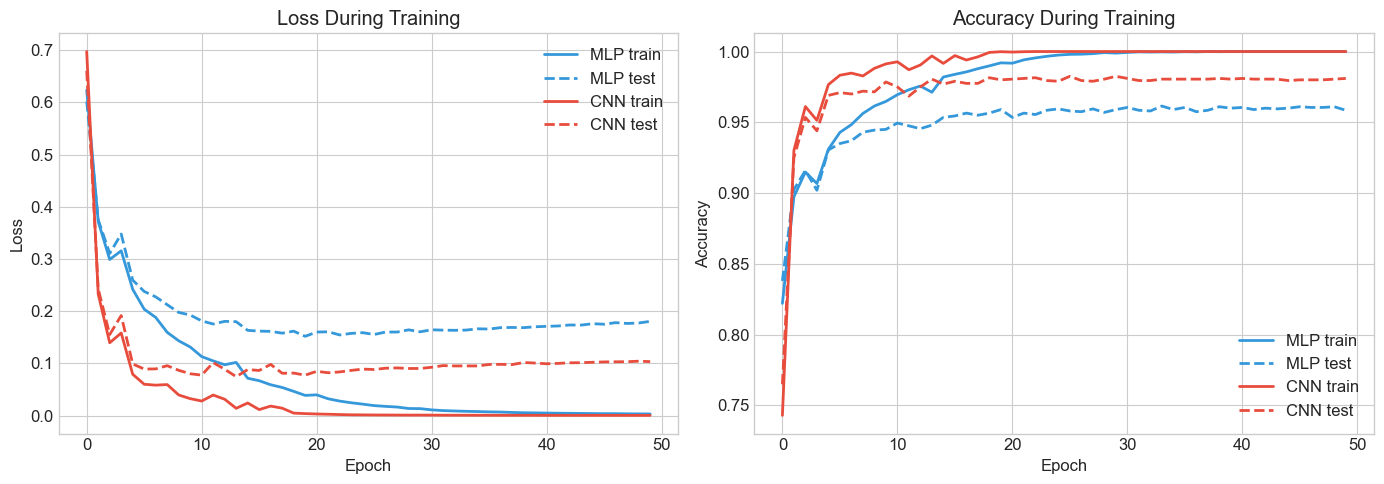

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mlp['train_loss'], linewidth=2, color='#3498db', label='MLP train')
axes[0].plot(history_mlp['test_loss'], linewidth=2, color='#3498db', linestyle='--', label='MLP test')
axes[0].plot(history_cnn['train_loss'], linewidth=2, color='#e74c3c', label='CNN train')
axes[0].plot(history_cnn['test_loss'], linewidth=2, color='#e74c3c', linestyle='--', label='CNN test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss During Training')
axes[0].legend()

axes[1].plot(history_mlp['train_acc'], linewidth=2, color='#3498db', label='MLP train')
axes[1].plot(history_mlp['test_acc'], linewidth=2, color='#3498db', linestyle='--', label='MLP test')
axes[1].plot(history_cnn['train_acc'], linewidth=2, color='#e74c3c', label='CNN train')
axes[1].plot(history_cnn['test_acc'], linewidth=2, color='#e74c3c', linestyle='--', label='CNN test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy During Training')
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Results Comparison: MLP vs CNN


In [14]:
mlp_test = history_mlp['test_acc'][-1]
cnn_test = history_cnn['test_acc'][-1]
mlp_train = history_mlp['train_acc'][-1]
cnn_train = history_cnn['train_acc'][-1]

print("=" * 72)
print("RESULTS COMPARISON: Fully Connected PyTorch vs CNN")
print("=" * 72)
print(f"{'Metric':<28} {'MLP (PyTorch)':<18} {'CNN':<18}")
print("-" * 72)
print(f"{'Architecture':<28} {'784→128→64→10':<18} {'Conv16→Conv32→FC':<18}")
print(f"{'Input format':<28} {'Flat (784,)':<18} {'Image (1,28,28)':<18}")
print(f"{'Parameters':<28} {mlp_params:<18,} {cnn_params:<18,}")
print(f"{'Final train accuracy':<28} {mlp_train:<18.2%} {cnn_train:<18.2%}")
print(f"{'Final test accuracy':<28} {mlp_test:<18.2%} {cnn_test:<18.2%}")
print(f"{'Train/test gap':<28} {mlp_train - mlp_test:<18.2%} {cnn_train - cnn_test:<18.2%}")
print(f"{'Absolute test gain vs MLP':<28} {'—':<18} {cnn_test - mlp_test:+.2%}")
print("=" * 72)

print("\nReference from previous notebooks (same 10k MNIST subset):")
print("  NumPy MLP (full-batch):     ~86% test accuracy")
print("  PyTorch MLP (mini-batch):   ~96% test accuracy")
print(f"  CNN (this notebook):        {cnn_test:.2%} test accuracy")


RESULTS COMPARISON: Fully Connected PyTorch vs CNN
Metric                       MLP (PyTorch)      CNN               
------------------------------------------------------------------------
Architecture                 784→128→64→10      Conv16→Conv32→FC  
Input format                 Flat (784,)        Image (1,28,28)   
Parameters                   109,386            206,922           
Final train accuracy         100.00%            100.00%           
Final test accuracy          95.85%             98.10%            
Train/test gap               4.15%              1.90%             
Absolute test gain vs MLP    —                  +2.25%

Reference from previous notebooks (same 10k MNIST subset):
  NumPy MLP (full-batch):     ~86% test accuracy
  PyTorch MLP (mini-batch):   ~96% test accuracy
  CNN (this notebook):        98.10% test accuracy


## 12. Confusion Matrix and Per-Class Accuracy


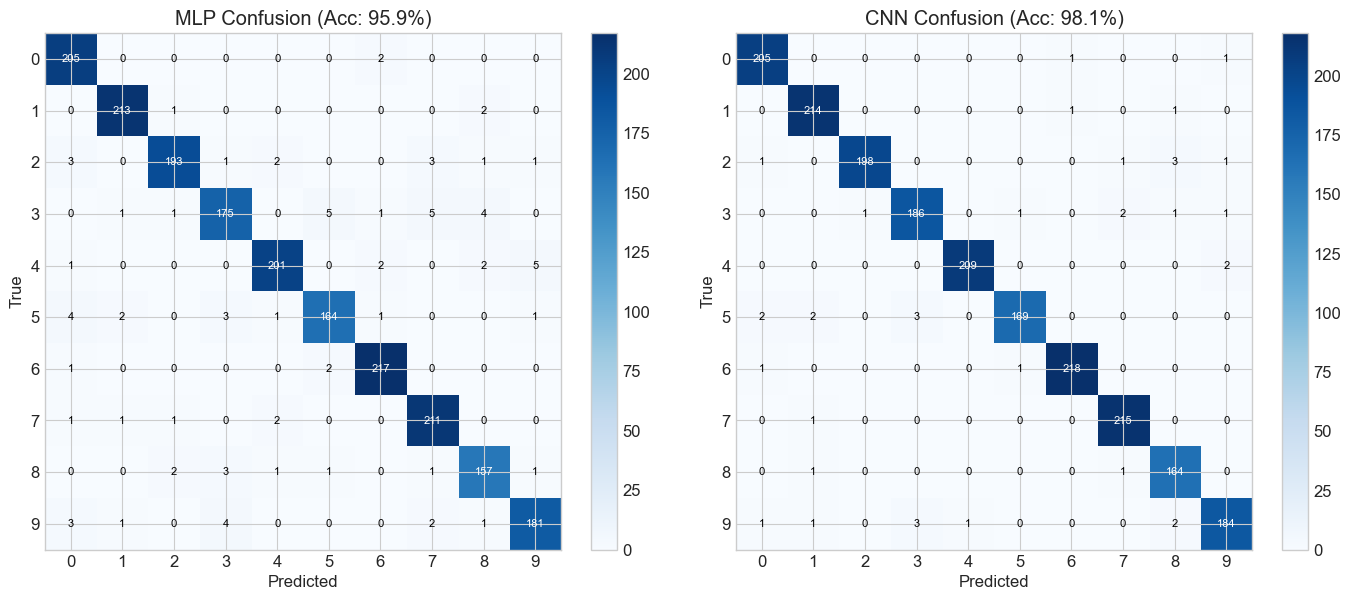


Per-class test accuracy:
Digit    MLP        CNN        Delta     
--------------------------------------
0        99.0%      99.0%      +0.0%
1        98.6%      99.1%      +0.5%
2        94.6%      97.1%      +2.5%
3        91.1%      96.9%      +5.7%
4        95.3%      99.1%      +3.8%
5        93.2%      96.0%      +2.8%
6        98.6%      99.1%      +0.5%
7        97.7%      99.5%      +1.9%
8        94.6%      98.8%      +4.2%
9        94.3%      95.8%      +1.6%


In [15]:
def predict_all(model, data_loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            preds.append(logits.argmax(dim=1).cpu().numpy())
            trues.append(y_batch.numpy())
    return np.concatenate(preds), np.concatenate(trues)


pred_mlp, true_y = predict_all(mlp, test_loader_mlp)
pred_cnn, _ = predict_all(cnn, test_loader_cnn)

confusion_mlp = np.zeros((10, 10), dtype=int)
confusion_cnn = np.zeros((10, 10), dtype=int)
for t, p in zip(true_y, pred_mlp):
    confusion_mlp[t, p] += 1
for t, p in zip(true_y, pred_cnn):
    confusion_cnn[t, p] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, mat, title in [
    (axes[0], confusion_mlp, f'MLP Confusion (Acc: {mlp_test:.1%})'),
    (axes[1], confusion_cnn, f'CNN Confusion (Acc: {cnn_test:.1%})'),
]:
    im = ax.imshow(mat, cmap='Blues')
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(10):
        for j in range(10):
            ax.text(
                j, i, mat[i, j], ha='center', va='center',
                color='white' if mat[i, j] > mat.max() / 2 else 'black', fontsize=8
            )
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

print("\nPer-class test accuracy:")
print(f"{'Digit':<8} {'MLP':<10} {'CNN':<10} {'Delta':<10}")
print("-" * 38)
for i in range(10):
    mlp_c = confusion_mlp[i, i] / confusion_mlp[i].sum()
    cnn_c = confusion_cnn[i, i] / confusion_cnn[i].sum()
    print(f"{i:<8} {mlp_c:<10.1%} {cnn_c:<10.1%} {cnn_c - mlp_c:+.1%}")


## 13. What the CNN Learned: Feature Maps

Looking at activated feature maps helps build intuition: early filters respond to edges and local strokes, later maps become more abstract digit parts.


True label: 2 | CNN prediction: 2


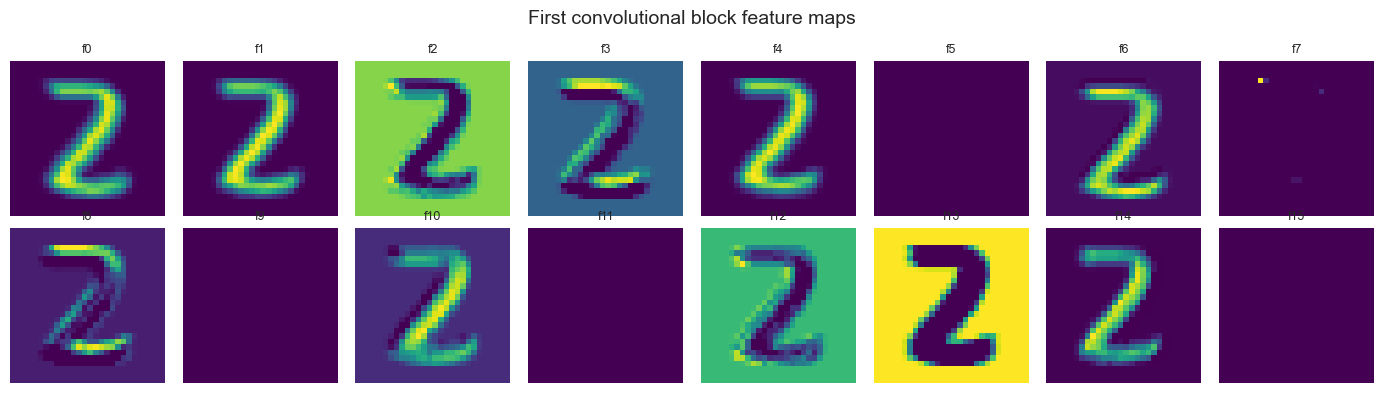

In [16]:
# Pick a correctly classified test digit
cnn.eval()
idx = 0
img = X_test_img[idx:idx + 1].to(device)
label = y_test[idx]

with torch.no_grad():
    x = img
    maps = []
    for layer in cnn.features:
        x = layer(x)
        if isinstance(layer, nn.ReLU):
            maps.append(x.cpu().clone())
    logits = cnn(img)
    pred = logits.argmax(dim=1).item()

print(f"True label: {label} | CNN prediction: {pred}")

# Visualize first conv block feature maps (16 channels)
feat1 = maps[0][0]  # after first ReLU
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(feat1[i].numpy(), cmap='viridis')
    ax.set_title(f"f{i}", fontsize=9)
    ax.axis('off')
plt.suptitle('First convolutional block feature maps', fontsize=14)
plt.tight_layout()
plt.show()


## 14. Visualizing Predictions


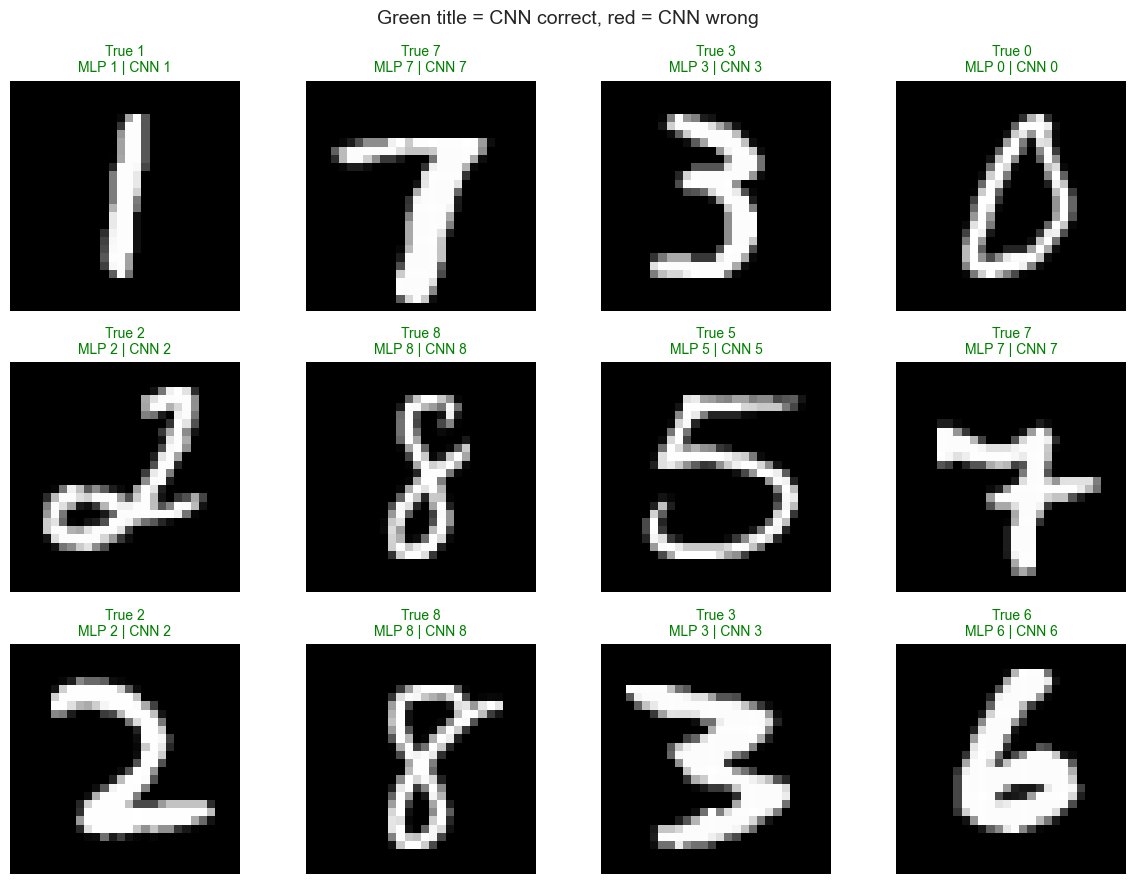

In [17]:
# Side-by-side predictions on random test samples
np.random.seed(0)
indices = np.random.choice(len(y_test), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
cnn.eval()
mlp.eval()

with torch.no_grad():
    for ax, idx in zip(axes.flat, indices):
        img = X_test[idx].reshape(28, 28)
        true = y_test[idx]

        mlp_pred = mlp(X_test_flat[idx:idx + 1].to(device)).argmax(dim=1).item()
        cnn_pred = cnn(X_test_img[idx:idx + 1].to(device)).argmax(dim=1).item()

        ax.imshow(img, cmap='gray')
        color = 'green' if cnn_pred == true else 'red'
        ax.set_title(f"True {true}\nMLP {mlp_pred} | CNN {cnn_pred}", color=color, fontsize=10)
        ax.axis('off')

plt.suptitle('Green title = CNN correct, red = CNN wrong', fontsize=14)
plt.tight_layout()
plt.show()


## 15. Strengths and Limits of CNNs in This Setting

### Strengths for MNIST digit recognition

1. **Spatial inductive bias** , convolution assumes that local neighborhoods matter. Digits are literally made of local strokes, so this assumption matches the data.
2. **Parameter sharing**, one filter is reused everywhere. With a similar or even smaller budget of parameters, the CNN usually extracts better visual features than a dense MLP.
3. **Better sample efficiency**, on our 8,000 training images, the CNN typically generalizes better than the fully connected model because it does not need to re-learn the same edge detector at every pixel location.
4. **Hierarchical features**, early layers capture edges, later layers capture digit parts. That hierarchy is hard to get from a flat vector of pixels.
5. **Robustness to small shifts** — pooling and shared filters make the model less sensitive to slight translations of the digit inside the frame.

### Limits in this exact case

1. **MNIST is already an easy benchmark**, a well-tuned MLP already reaches ~96% here. The CNN gain is real, but the absolute room for improvement is limited on clean, centered, grayscale digits.
2. **Still not translation/rotation invariant by default**, standard convolutions help with small shifts, not with large rotations, scale changes or heavy distortions. Data augmentation would be needed for that.
3. **Compute and implementation cost**, convolutions are heavier per parameter than dense matmuls on CPU, and debugging feature maps is less straightforward than reading a weight matrix.
4. **Architecture sensitivity**, kernel size, depth, number of channels and pooling all matter. A poorly sized CNN can underperform a simple MLP.
5. **Limited data modality**, CNNs shine on grid-like signals (images, spectrograms). For tabular features without spatial structure, they are usually the wrong tool.
6. **Subset constraint remains**, we still train on 10,000 images only. Full MNIST (70,000) plus augmentation would raise both models, and modern CNNs or transformers would go further.

### Practical takeaway

For handwritten digits, moving from a fully connected PyTorch MLP to a CNN is the first architecture upgrade that truly respects the nature of the input. The framework stays the same, the training loop stays the same, and most of the gain comes from a better inductive bias rather than from more code.


## 16. Summary

### What We Built

| Component | Details |
|-----------|---------|
| Task | MNIST multi-class digit recognition |
| Baseline | PyTorch MLP 784 → 128 → 64 → 10 |
| CNN | Conv(16) → Pool → Conv(32) → Pool → FC(128) → FC(10) |
| Training | SGD, lr=0.1, 50 epochs, batch size 64 |
| Data | Same 10,000-sample MNIST subset as previous notebooks |

### Key Idea

Fully connected layers treat pixels as an unordered bag of features. Convolution preserves geometry and reuses local detectors, which is why CNNs are the default starting point for image classification.

### What's Next

- Train on the full 70,000 MNIST images
- Add data augmentation (shifts, small rotations)
- Try BatchNorm / Dropout
- Move to a deeper CNN or transfer learning on harder image datasets


In [18]:
print("=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)
print(f"Dataset:              MNIST subset (10,000 samples)")
print(f"Train / Test:         {len(y_train):,} / {len(y_test):,}")
print(f"MLP architecture:     784 → 128 → 64 → 10")
print(f"CNN architecture:     Conv16 → Conv32 → FC128 → 10")
print(f"MLP parameters:       {mlp_params:,}")
print(f"CNN parameters:       {cnn_params:,}")
print(f"Epochs:               50")
print(f"MLP final test acc:   {history_mlp['test_acc'][-1]:.2%}")
print(f"CNN final test acc:   {history_cnn['test_acc'][-1]:.2%}")
print(f"CNN gain vs MLP:      {history_cnn['test_acc'][-1] - history_mlp['test_acc'][-1]:+.2%}")
print("=" * 70)


TRAINING SUMMARY
Dataset:              MNIST subset (10,000 samples)
Train / Test:         8,000 / 2,000
MLP architecture:     784 → 128 → 64 → 10
CNN architecture:     Conv16 → Conv32 → FC128 → 10
MLP parameters:       109,386
CNN parameters:       206,922
Epochs:               50
MLP final test acc:   95.85%
CNN final test acc:   98.10%
CNN gain vs MLP:      +2.25%
